/var/folders/yp/078pyxw11mq6g7sd_2ty18z80000gn/T/ipykernel_23696/1945609799.py:4: DeprecationWarning: Using Qiskit with Python 3.9 is deprecated as of the 2.1.0 release. Support for running Qiskit with Python 3.9 will be removed in the 2.3.0 release, which coincides with when Python 3.9 goes end of life.
  from qiskit import QuantumCircuit



UNKNOWN ROTATION TOMOGRAPHY

Quantum Circuit:
        ┌─────────┐ ░ ┌─┐
     q: ┤ Ry(π/3) ├─░─┤M├
        └─────────┘ ░ └╥┘
meas: 1/═══════════════╩═
                       0 

MEASUREMENT RESULTS
Shots       : 10000
0 count     : 7474
1 count     : 2526

Measured P(0): 0.7474
Measured P(1): 0.2526

TOMOGRAPHY ESTIMATION
Estimated angle : 60.34 degrees
Estimation error: 0.34 degrees

Formula used:
P(1) = sin²(theta / 2)
theta = 2 × arcsin(sqrt(P(1)))


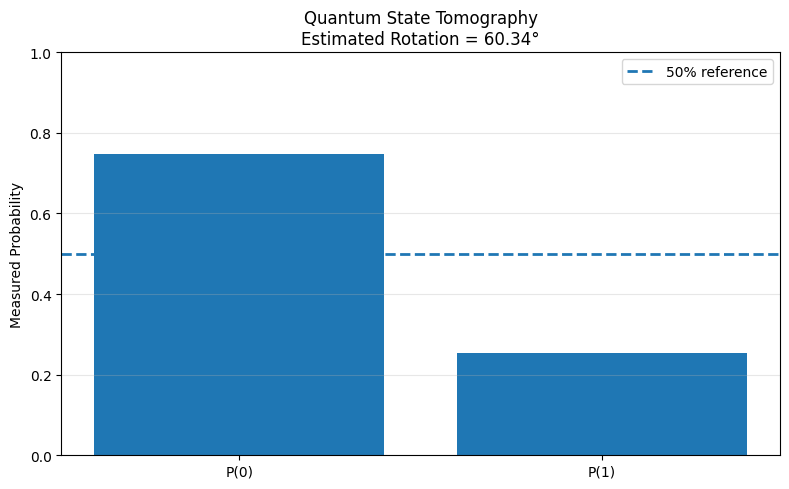

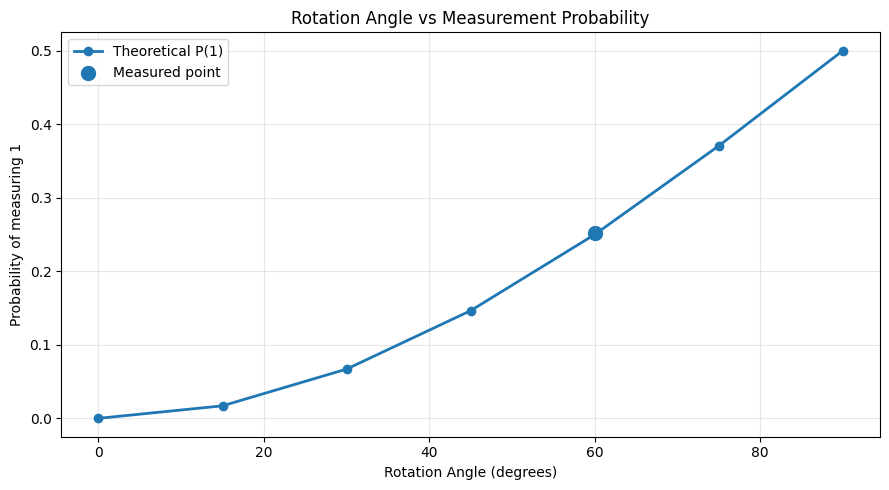

In [1]:
import math
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler

shots = 10000

hidden_angle = 60

theta = math.radians(hidden_angle)

qc = QuantumCircuit(1)

qc.ry(theta, 0)
qc.measure_all()

print("\nUNKNOWN ROTATION TOMOGRAPHY")
print("=" * 60)

print("\nQuantum Circuit:")
print(qc.draw())

sampler = StatevectorSampler()

result = sampler.run(
    [qc],
    shots=shots
).result()

counts = result[0].data.meas.get_counts()

zeros = counts.get("0", 0)
ones = counts.get("1", 0)

p0 = zeros / shots
p1 = ones / shots

estimated_theta = 2 * math.asin(
    math.sqrt(p1)
)

estimated_angle = math.degrees(
    estimated_theta
)

error = abs(
    estimated_angle - hidden_angle
)

print("\nMEASUREMENT RESULTS")
print("=" * 60)

print(f"Shots       : {shots}")
print(f"0 count     : {zeros}")
print(f"1 count     : {ones}")

print(f"\nMeasured P(0): {p0:.4f}")
print(f"Measured P(1): {p1:.4f}")

print("\nTOMOGRAPHY ESTIMATION")
print("=" * 60)

print(f"Estimated angle : {estimated_angle:.2f} degrees")

print(f"Estimation error: {error:.2f} degrees")

print("\nFormula used:")
print("P(1) = sin²(theta / 2)")
print("theta = 2 × arcsin(sqrt(P(1)))")

labels = [
    "P(0)",
    "P(1)"
]

probabilities = [
    p0,
    p1
]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    labels,
    probabilities
)

plt.axhline(
    0.5,
    linestyle="--",
    linewidth=2,
    label="50% reference"
)

plt.ylabel("Measured Probability")

plt.title(
    f"Quantum State Tomography\nEstimated Rotation = {estimated_angle:.2f}°"
)

plt.ylim(0, 1)

plt.grid(axis="y", alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

angles = [0, 15, 30, 45, 60, 75, 90]

theoretical_p1 = [
    math.sin(math.radians(a) / 2) ** 2
    for a in angles
]

plt.figure(figsize=(9, 5))

plt.plot(
    angles,
    theoretical_p1,
    marker="o",
    linewidth=2,
    label="Theoretical P(1)"
)

plt.scatter(
    [hidden_angle],
    [p1],
    s=100,
    label="Measured point"
)

plt.xlabel("Rotation Angle (degrees)")

plt.ylabel("Probability of measuring 1")

plt.title("Rotation Angle vs Measurement Probability")

plt.grid(True, alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()